## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Section 004 - Spring 2022)

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.



<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

___
# Late uploads will be graded as 0 points.

Please finish uploading this quiz notebook to D2L before 3:35:00 p.m.

You can upload this notebook to D2L multiple times during the quiz, but only the last update counts.

If you get less than 70 regular points, you cannot get benifit from bonus points.

___
### &#9989;&nbsp; Question 0: Importing modules (5 points)

Please **import** all modules you need in this quiz in the following cell. Do not import unnecessary ones.

You may come back to this question later on. Keep this in mind.

In [1]:
# Put your code here

In [2]:
### Answer ###

# NumPy
import numpy as np
# Pyplot
import matplotlib.pyplot as plt
%matplotlib inline
# curve_fit from SciPy
from scipy.optimize import curve_fit

### Answer ###

___
### &#9989;&nbsp; Question 1: Preparing data (5 points)

Here we generate data for fitting.

The $x$ and $y$ components of data for this quiz are the following:

    y = np.array([0.16243454, 0.03882436, 0.14718282, 0.19270314, 0.48654076,
       0.26984613, 0.77448118, 0.62387931, 0.83190391, 0.87506296,
       1.14621079, 0.74398593, 0.86775828, 0.81159456, 0.91337694,
       0.64001087, 0.68275718, 0.56221416, 0.60422137, 0.60828152,
       0.38993808])
    x = np.linspace(0, 1, len(y))
       
Please **plot** the data using separated markers, and **answer** the following question:
- Please use plain English to describe the given $x$ values.

In [3]:
# Put your code here

y = np.array([0.16243454, 0.03882436, 0.14718282, 0.19270314, 0.48654076,
   0.26984613, 0.77448118, 0.62387931, 0.83190391, 0.87506296,
   1.14621079, 0.74398593, 0.86775828, 0.81159456, 0.91337694,
   0.64001087, 0.68275718, 0.56221416, 0.60422137, 0.60828152,
   0.38993808])
x = np.linspace(0, 1, len(y))

<font size=+3>&#9998;</font> *Put your answer here.*
- answer

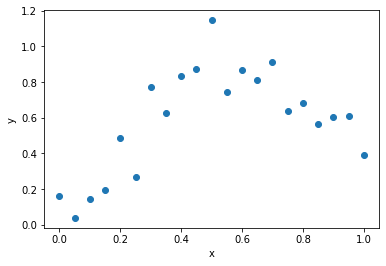

In [4]:
### Answer ###

y = np.array([0.16243454, 0.03882436, 0.14718282, 0.19270314, 0.48654076,
   0.26984613, 0.77448118, 0.62387931, 0.83190391, 0.87506296,
   1.14621079, 0.74398593, 0.86775828, 0.81159456, 0.91337694,
   0.64001087, 0.68275718, 0.56221416, 0.60422137, 0.60828152,
   0.38993808])
x = np.linspace(0, 1, len(y))

plt.figure()
plt.plot(x, y, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# - The $x$ uniformly spans from 0 to 1 with 21 points.

### Answer ###

In [10]:
### Answer ###

# code to generate data

x = np.linspace(0, 1, 21)
y = np.zeros_like(x)
for i in range(x.size):
    if x[i] <= 0.5:
        y[i]= 2 * x[i]
    else:
        y[i]= 1.5 - x[i]

np.random.seed(seed = 1)
y = y + np.random.normal(0, 0.1, x.size)

y

### Answer ###

array([0.16243454, 0.03882436, 0.14718282, 0.19270314, 0.48654076,
       0.26984613, 0.77448118, 0.62387931, 0.83190391, 0.87506296,
       1.14621079, 0.74398593, 0.86775828, 0.81159456, 0.91337694,
       0.64001087, 0.68275718, 0.56221416, 0.60422137, 0.60828152,
       0.38993808])

___
### &#9989;&nbsp; Question 2: Fit quadratic functions (30 points)
       
Please **fit** a quadratic function, i.e., a second-order polynomial, to the given data, and **plot** your predicted function on the top of the given data.

For example,
$$y(x) = 23 x^2 + 8$$
is a quadratic function since it is a polynomial with highest order two.

While plotting the predicted function, please use a denser and larger $x$ values, say, `np.linspace(-0.2, 1.2, 101)`. Remember to add legends.

In [6]:
# Put your code here

The best parameters are  [-0.05825077  3.09538378 -2.63485084]


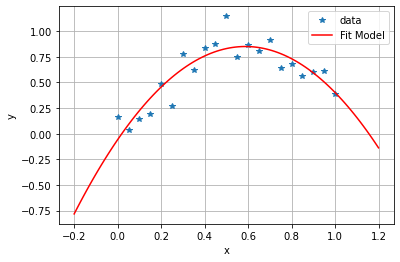

In [7]:
### Answer ###

def fitting_quad(x, p0, p1, p2):
    return p0 + p1 * x + p2 * x ** 2

x_plot = np.linspace(-0.2, 1.2, 101)


popt_quad, pcov = curve_fit(fitting_quad, x, y)
print('The best parameters are ', popt_quad)
y_quad = fitting_quad(x,popt_quad[0],popt_quad[1],popt_quad[2])
y_quad_plot = fitting_quad(x_plot,popt_quad[0],popt_quad[1],popt_quad[2])
plt.plot( x, y, "*", label='data' )
plt.plot( x_plot, y_quad_plot, 'r',label="Fit Model" )
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

### Answer ###

___
### &#9989;&nbsp; Question 3: Fit piecewise linear functions (40 points)
       
Similar to Question 2, now we fit to given data a new kind of function --- piecewise linear function.

For example,
$$
y (x) = 2 x + 7, \quad x \leq 0.5
\\
y (x) = 1.5 - x, \quad x > 0.5
$$
is a piecewise linear function, since on both domains $x \leq 0.5$ and $x > 0.5$, the functions $y = y(x)$ are linear functions (first-order polynomials).

In this question, please **fit** a piecewise linear function to the given data. For simplicity, we fix the two pieces / domains as $x \leq 0.5$ and $x > 0.5$.

Then **plot** your predicted piecewise linear function on the top of the given data, using two separated segments of $x$ values `np.linspace(-0.2, 0.5, 51)` and `np.linspace(0.501, 1.2, 51)`.

In [8]:
# Put your code here

The best parameters are  [ 2.08514394 -0.01682509 -0.85459103  1.34472193]


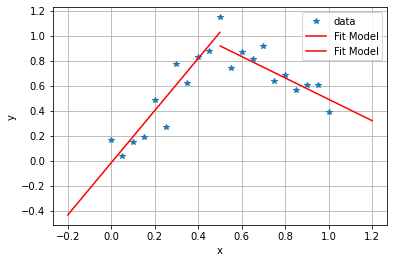

In [11]:
### Answer ###
def fitting_pwl(x, m1, b1, m2, b2):
    y=np.zeros_like(x)
    for i in range(x.size):
        if x[i] <= 0.5:
            y[i] = m1*x[i] + b1
        else:
            y[i] = m2*x[i] + b2
    return y

popt_pwl, pcov = curve_fit(fitting_pwl, x, y)
print('The best parameters are ', popt_pwl)
x_plot1 = np.linspace(-0.2, 0.5, 51)
x_plot2 = np.linspace(0.501, 1.2, 51)

y_pwl = fitting_pwl(x,popt_pwl[0],popt_pwl[1],popt_pwl[2],popt_pwl[3])
y_pwl_plot1 = fitting_pwl(x_plot1,popt_pwl[0],popt_pwl[1],popt_pwl[2],popt_pwl[3])
y_pwl_plot2 = fitting_pwl(x_plot2,popt_pwl[0],popt_pwl[1],popt_pwl[2],popt_pwl[3])
plt.plot( x, y, "*", label='data' )
plt.plot( x_plot1, y_pwl_plot1, 'r',label="Fit Model" )
plt.plot( x_plot2, y_pwl_plot2, 'r',label="Fit Model" )

plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()
# print('MSE = ' + str(MSE(y, y_pwl)))
### Answer ###

___
### &#9989;&nbsp; Question 4: Calculate MSE (10 points)

Given the data $\{ (a_i, b_i) \} _{i = 1} ^N$, and the fitted model $f$, the mean squared error (MSE) is
$$ MSE := \frac{1}{N}\sum_{i=1}^{N} (f(a_i) - b_i) ^2.$$
This is the same as the definition in Homework 4, Question 6.

Now please **calculate** the MSE for both fittings in Questions 2 and 3. 

In [12]:
# Put your code here

In [13]:
### Answer ###
def MSE(data, fit):
    return np.sum((data - fit) ** 2) / len(data)
print('quad MSE = ' + str(MSE(y, y_quad)))
print('pwl MSE = ' + str(MSE(y, y_pwl)))
### Answer ###

quad MSE = 0.017304793447789357
pwl MSE = 0.011089337371571608


___
### &#9989;&nbsp; Question 3': Fit continuous piecewise linear functions (20 bonus points)

In Question 3, the predicted piecewise linear function is not continuous at $x=0.5$. Please **fit** a continuous piecewise linear function to the data, and **plot** it  on the top of the given data, using $x$ values `np.linspace(-0.2, 1.2, 101)`. Then **calculate** the MSE.

In [14]:
# Put your code here

The best parameters are  [ 1.95967622  0.00199507 -1.03861035]


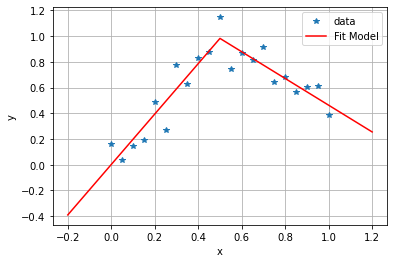

MSE = 0.011801232330279677


In [15]:
### Answer ###
def fitting_cpwl(x, m1, b1, m2):
    c = 0.5
    y=np.zeros_like(x)
    for i in range(x.size):
        if x[i] <= c:
            y[i] = m1*x[i] + b1
        else:
            y[i] = m2*x[i] + (m1-m2)*c + b1
    return y
x_plot = np.linspace(-0.2, 1.2, 101)


popt_cpwl, pcov = curve_fit(fitting_cpwl, x, y)
print('The best parameters are ', popt_cpwl)
y_cpwl = fitting_cpwl(x,popt_cpwl[0],popt_cpwl[1],popt_cpwl[2])

y_cpwl_plot = fitting_cpwl(x_plot,popt_cpwl[0],popt_cpwl[1],popt_cpwl[2])


plt.plot( x, y, "*", label='data' )
plt.plot( x_plot, y_cpwl_plot, 'r',label="Fit Model" )
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()
print('MSE = ' + str(MSE(y, y_cpwl)))
### Answer ###

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page. Go to "Quizzes" -> "Quiz 4" -> "Please drop your Quiz 4 notebook here", and upload your notebook there.